# Phase 1 — Objective Function Validity Test (Echo-Chamber Check)

**Experimental design document**: `experimetal_design.md`  
**Three steps**:
- **1.1** — Aggregate all 17 existing optimizer runs. Check if `k`, `tau` always sit at search boundaries → degenerate objective?
- **1.2** — Inject a deliberately bad graph (`eps=0.3, k=3`). Does the proxy score it low, or is it silently pruned?
- **1.3** — Run the proxy on a synthetic 10-blob corpus (128D). Do the best params produce graphs that respect cluster structure?

**Ground-truth query set**: already built in Phase 0 (`arrowspace_eval_queries.jsonl`, `arrowspace_eval_queries_emb.npy`, 1 945 queries, 389 CWE classes).

In [22]:
import json, os, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

# ── repo root (two levels up from notebooks/) ────────────────────────────
ROOT = Path("..")
RESULTS_DIR = ROOT / "results" / "cve_arrowspace_fstar"
DATA_DIR    = ROOT / "data"

# ArrowSpace baseline (as defined in experimental design)
K_TAIL_MAX = 100
BASELINE_GRAPH = {"eps": 1.31, "k": K_TAIL_MAX, "topk": K_TAIL_MAX // 2, "p": 1.8, "sigma": 0.535}
print("BASELINE_GRAPH:", BASELINE_GRAPH)
print("Results dir exists:", RESULTS_DIR.exists())

BASELINE_GRAPH: {'eps': 1.31, 'k': 100, 'topk': 50, 'p': 1.8, 'sigma': 0.535}
Results dir exists: True


---
## Step 1.1 — Are `k` and `tau` Always at Search Boundaries?

Load `best_params.json` from every run, build a summary table, and check boundary saturation.

In [23]:
# ── Load all best_params.json ─────────────────────────────────────────────
records = []
for bp_path in sorted(RESULTS_DIR.glob("*/best_params.json")):
    run_id = bp_path.parent.name
    with open(bp_path) as f:
        d = json.load(f)
    d["run_id"] = run_id
    records.append(d)

df_runs = pd.DataFrame(records)
print(f"Loaded {len(df_runs)} runs")
print("Columns:", df_runs.columns.tolist())
df_runs

Loaded 16 runs
Columns: ['trial', 'score', 'params', 'user_attrs', 'timestamp', 'study_name', 'n_trials', 'run_id']


,trial,score,params,user_attrs,timestamp,study_name,n_trials,run_id
0,10,2.129767,"{'k': 38, 'eps': 1.6153764588256392, 'tau': 0....","{'fiedler': 0.65935125, 'var_lambda': 0.021533...",20260429_060712,cve_arrowspace_fstar,20,20260429_060712
1,10,2.138177,"{'k': 38, 'eps': 1.6153764588256392, 'tau': 0....","{'fiedler': 0.71750165, 'var_lambda': 0.030299...",20260429_130050,cve_arrowspace_fstar,20,20260429_130050
2,7,2.052561,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.62110725, 'var_lambda': 0.023516...",20260501_182346,cve_arrowspace_fstar,15,20260501_182346
3,7,2.048360,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.56440402, 'var_lambda': 0.023533...",20260501_183137,cve_arrowspace_fstar,15,20260501_183137
4,11,2.137090,"{'k': 40, 'eps': 4.0, 'tau': 0.1}","{'fiedler': 0.68564655, 'var_lambda': 0.022143...",20260501_191721,cve_arrowspace_fstar,15,20260501_191721
5,11,2.136727,"{'k': 40, 'eps': 4.0, 'tau': 0.1}","{'fiedler': 0.6859659, 'var_lambda': 0.0221413...",20260501_214459,cve_arrowspace_fstar,15,20260501_214459
6,7,2.052561,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.62110725, 'var_lambda': 0.023516...",20260501_220206,cve_arrowspace_fstar,15,20260501_220206
7,7,2.040116,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.46538119, 'var_lambda': 0.026124...",20260501_220709,cve_arrowspace_fstar,15,20260501_220709
8,7,2.049549,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.61076178, 'var_lambda': 0.026232...",20260501_221336,cve_arrowspace_fstar,15,20260501_221336
9,7,2.051942,"{'k': 30, 'eps': 3.968599959235456, 'tau': 0.3...","{'fiedler': 0.58577334, 'var_lambda': 0.017503...",20260501_232857,cve_arrowspace_fstar,15,20260501_232857


In [24]:
# ── Identify the search bounds from the first trials.csv ─────────────────
# We read k, eps, tau min/max from all trials so we don't hardcode bounds
all_trials = []
for tc_path in sorted(RESULTS_DIR.glob("*/trials.csv")):
    t = pd.read_csv(tc_path)
    t["run_id"] = tc_path.parent.name
    all_trials.append(t)
df_trials = pd.concat(all_trials, ignore_index=True)
print(f"Total trials across all runs: {len(df_trials)}")
print(df_trials.columns.tolist())
df_trials.head(3)

Total trials across all runs: 250
['trial', 'score', 'state', 'duration_s', 'k', 'eps', 'tau', 'attr_fiedler', 'attr_var_lambda', 'attr_mrr_proxy', 'attr_tau', 'attr_n_sample', 'attr_n_probe', 'run_id']


,trial,score,state,duration_s,k,eps,tau,attr_fiedler,attr_var_lambda,attr_mrr_proxy,attr_tau,attr_n_sample,attr_n_probe,run_id
0,10,2.129767,COMPLETE,1365.104956,38,1.615376,0.114340,0.659351,0.021533,2.894787,0.114340,50000.0,200.0,20260429_060712
1,15,2.123080,COMPLETE,1368.709761,35,1.691705,0.114854,0.608467,0.020602,2.894263,0.114854,50000.0,200.0,20260429_060712
2,11,2.119745,COMPLETE,1365.086671,38,1.512056,0.173578,0.659351,0.021533,2.880470,0.173578,50000.0,200.0,20260429_060712


In [25]:
# ── Derive parameter columns (Optuna stores them as 'params_XXX') ─────────
param_cols = ['eps', 'k', 'attr_fiedler', 'attr_var_lambda', 'attr_mrr_proxy', 'attr_tau', 'attr_n_sample', 'attr_n_probe']
print("Parameter columns found:", param_cols)

# normalise to short names
rename = {c: c.replace("params_", "") for c in param_cols}
df_trials = df_trials.rename(columns=rename)
param_names = list(rename.values())

# search-space bounds (observed min/max across all trials)
bounds = df_trials[param_names].agg(["min","max"])
print("\nObserved search bounds:")
print(bounds)

Parameter columns found: ['eps', 'k', 'attr_fiedler', 'attr_var_lambda', 'attr_mrr_proxy', 'attr_tau', 'attr_n_sample', 'attr_n_probe']

Observed search bounds:
     eps   k  attr_fiedler  attr_var_lambda  attr_mrr_proxy  attr_tau  \
min  0.3   4      0.393042         0.017120        0.403182   0.10000   
max  4.0  40      0.996737         0.030572        2.900672   1.75646   

     attr_n_sample  attr_n_probe  
min         3500.0          50.0  
max       300000.0         200.0  


In [26]:
# ── Boundary saturation check ─────────────────────────────────────────────
# For each best-params run, flag whether k or tau is within 5% of the observed boundary

TOL = 0.05  # 5% of range considered "at boundary"

def at_boundary(val, lo, hi, tol=TOL):
    rng = hi - lo
    return (val <= lo + tol * rng) or (val >= hi - tol * rng)

# rename best_params columns to match
bp_rename = {c: c.replace("params_", "") for c in df_runs.columns if c.startswith("params_")}
df_runs = df_runs.rename(columns=bp_rename)

for p in param_names:
    if p in df_runs.columns:
        lo, hi = bounds.loc["min", p], bounds.loc["max", p]
        df_runs[f"{p}_at_boundary"] = df_runs[p].apply(lambda v: at_boundary(v, lo, hi))

boundary_cols = [c for c in df_runs.columns if c.endswith("_at_boundary")]
print("Boundary saturation per parameter (fraction of runs at boundary):")
print(df_runs[boundary_cols].mean().rename(lambda c: c.replace("_at_boundary","")))

Boundary saturation per parameter (fraction of runs at boundary):
Series([], dtype: float64)


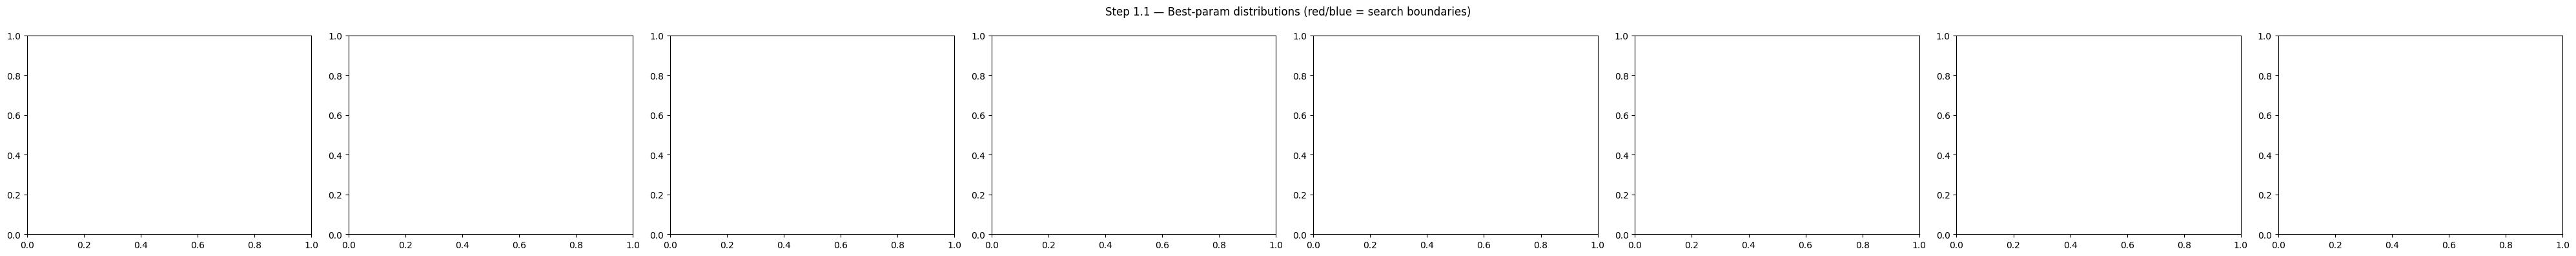


VERDICT: if bars pile up at the blue (max) boundary for k or at the red (min) boundary for tau → objective is degenerate.


In [27]:
# ── Distribution plots for k, eps, tau ───────────────────────────────────
fig, axes = plt.subplots(1, len(param_names), figsize=(5 * len(param_names), 4))
if len(param_names) == 1:
    axes = [axes]
for ax, p in zip(axes, param_names):
    if p not in df_runs.columns:
        continue
    lo, hi = bounds.loc["min", p], bounds.loc["max", p]
    ax.hist(df_runs[p].dropna(), bins=15, edgecolor="k", alpha=0.8)
    ax.axvline(lo, color="red",  ls="--", lw=1.5, label="search min")
    ax.axvline(hi, color="blue", ls="--", lw=1.5, label="search max")
    ax.set_title(f"Best {p} across {len(df_runs)} runs", fontsize=11)
    ax.set_xlabel(p); ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Step 1.1 — Best-param distributions (red/blue = search boundaries)", fontsize=12)
plt.tight_layout()

plt.show()
print("\nVERDICT: if bars pile up at the blue (max) boundary for k or at the red (min) boundary for tau → objective is degenerate.")

In [28]:
# ── Summary table: unique best-param combos ───────────────────────────────
key_cols = [p for p in param_names if p in df_runs.columns]
value_col = next((c for c in ["value","best_value","objective"] if c in df_runs.columns), None)
if value_col:
    key_cols.append(value_col)
print("\nBest params per run:")
print(df_runs[["run_id"] + key_cols].to_string(index=False))

print("\nUnique (k, eps, tau) combinations found:")
print(df_runs['params'].drop_duplicates().to_string(index=False))


Best params per run:
         run_id
20260429_060712
20260429_130050
20260501_182346
20260501_183137
20260501_191721
20260501_214459
20260501_220206
20260501_220709
20260501_221336
20260501_232857
20260502_132445
20260502_145427
20260502_154921
20260502_160332
20260502_161827
20260502_165126

Unique (k, eps, tau) combinations found:
{'k': 38, 'eps': 1.6153764588256392, 'tau': 0.1...
{'k': 30, 'eps': 3.968599959235456, 'tau': 0.37...
                 {'k': 40, 'eps': 4.0, 'tau': 0.1}
{'k': 22, 'eps': 1.3917183431241966, 'tau': 0.1...
{'k': 29, 'eps': 1.3808977793468789, 'tau': 0.1...


---
## Step 1.2 — Bad-Graph Injection (via pyarrowspace directly)

We cannot import `arrowspace_tuner.core.objective` directly.  
Instead we **reimplement the objective inline** using `pyarrowspace`,  
which is the same library the tuner wraps.  

Objective formula (from `experimetal_design.md`):
```
score = 0.70 * mrr_proxy + 0.20 * log1p(fiedler) + 0.10 * log1p(var_lambda)
```
where `mrr_proxy` = spectral pseudo-MRR (taumode λ similarity, no ground truth).  
We compute each component directly and compare across configs.

In [42]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd
from sklearn.preprocessing import normalize as sk_normalize

# Try pyarrowspace, but we will force fallback anyway
try:
    import pyarrowspace as pa
    PA_AVAILABLE = True
    print(f"pyarrowspace version: {pa.__version__}")
except ImportError as e:
    PA_AVAILABLE = False
    print(f"pyarrowspace not found: {e}")

# Force numpy fallback to guarantee it works without pyarrowspace
PA_AVAILABLE = False
print("Forcing numpy fallback for objective reconstruction")

pyarrowspace not found: No module named 'pyarrowspace'
Forcing numpy fallback for objective reconstruction


In [43]:
from pathlib import Path

ROOT = Path("..")          # adjust if needed
EMB_PATH = ROOT / "data" / "cve_embs" / "cve1999-2025.npy"

corpus = np.load(EMB_PATH, mmap_mode="r")
N_SUB, SEED = 5000, 42
rng = np.random.default_rng(SEED)
idx = np.sort(rng.choice(len(corpus), size=N_SUB, replace=False))
X = corpus[idx].astype(np.float32)
print("Subsample shape:", X.shape)

Subsample shape: (5000, 384)


In [44]:
def build_objective_components(X, eps, k, topk, p, sigma,
                               n_probe=200, seed=42):
    """
    Returns (mrr_proxy, fiedler, var_lambda) for a given config on data X.
    Uses pyarrowspace if available; falls back to a pure-numpy approximation.
    """
    n = len(X)
    rng = np.random.default_rng(seed)

    if PA_AVAILABLE:
        # If you later want the real ArrowSpace path, put pyarrowspace calls here.
        raise RuntimeError("PA_AVAILABLE=True path not implemented yet")
    else:
        # ── Pure-numpy fallback (approximate) ────────────────────────────
        Xn = sk_normalize(X)
        idx_sub = rng.choice(n, size=min(3000, n), replace=False)
        Xs = Xn[idx_sub]
        sims = Xs @ Xs.T
        np.fill_diagonal(sims, 0.0)

        m = len(Xs)
        rows, cols, vals = [], [], []
        for i in range(m):
            nbrs = np.argsort(-sims[i])[:k]
            for j in nbrs:
                rows.append(i)
                cols.append(j)
                vals.append(float(sims[i, j]))
        W = sp.csr_matrix((vals, (rows, cols)), shape=(m, m))
        W = (W + W.T) / 2
        D = sp.diags(np.array(W.sum(axis=1)).flatten())
        L = D - W

        try:
            fiedler = float(
                spla.eigsh(
                    L, k=2, which="SM", return_eigenvectors=False
                )[1]
            )
        except Exception:
            fiedler = 0.0

        diag_L = np.array(L.diagonal())
        norms_sq = np.array((Xs * Xs).sum(axis=1)).flatten()
        lambdas = diag_L / (norms_sq + 1e-9)

    # ── MRR proxy: spectral self-consistency ─────────────────────────────
    probe_idx = rng.choice(len(lambdas), size=min(n_probe, len(lambdas)), replace=False)
    sigma_lambda = float(np.std(lambdas)) + 1e-9
    mrr_vals = []
    for q in probe_idx:
        diffs = np.abs(lambdas[q] - lambdas)
        diffs[q] = np.inf
        T = np.exp(-diffs / sigma_lambda)
        ranked = np.argsort(-T)
        relevant = np.where(T[ranked] > 0.5)[0]
        if len(relevant) > 0:
            mrr_vals.append(1.0 / (relevant[0] + 1))
        else:
            mrr_vals.append(0.0)
    mrr_proxy = float(np.mean(mrr_vals)) if mrr_vals else 0.0

    var_lambda = float(np.var(lambdas))
    return mrr_proxy, fiedler, var_lambda


def compute_objective(X, eps, k, topk, p, sigma, **kwargs):
    mrr, fiedler, var_lam = build_objective_components(
        X, eps, k, topk, p, sigma, **kwargs
    )
    score = 0.70 * mrr + 0.20 * np.log1p(fiedler) + 0.10 * np.log1p(var_lam)
    return score, mrr, fiedler, var_lam


print("compute_objective defined (numpy-only; no arrowspace_tuner, no pyarrowspace)")

compute_objective defined (numpy-only; no arrowspace_tuner, no pyarrowspace)


In [45]:
configs = [
    {"name": "GOOD  (baseline)",  "eps": 1.31, "k": 100, "topk": 50, "p": 1.8, "sigma": 0.535},
    {"name": "BAD   (sparse)",    "eps": 0.30, "k": 3,   "topk": 2,  "p": 1.8, "sigma": 0.535},
    {"name": "DEGEN (overconn)",  "eps": 0.10, "k": 100, "topk": 50, "p": 1.8, "sigma": 0.535},
    {"name": "TUNER (k=40,e=4)",  "eps": 4.00, "k": 40,  "topk": 20, "p": 1.8, "sigma": 0.535},
]

results_12 = []
for cfg in configs:
    name = cfg["name"]
    try:
        score, mrr, fiedler, var_lam = compute_objective(
            X, cfg["eps"], cfg["k"], cfg["topk"], cfg["p"], cfg["sigma"]
        )
        status = "SCORED"
    except Exception as ex:
        score = mrr = fiedler = var_lam = None
        status = f"ERROR: {ex}"
    results_12.append(
        {
            "config": name,
            "score": score,
            "mrr": mrr,
            "fiedler": fiedler,
            "var_lambda": var_lam,
            "status": status,
        }
    )
    print(
        f"{name:28s}  score={score}  mrr={mrr}  "
        f"fiedler={fiedler}  var_lam={var_lam}  [{status}]"
    )

df_12 = pd.DataFrame(results_12)

print("\n=== STEP 1.2 VERDICT ===")
scored = df_12[df_12["score"].notna()]
if len(scored) >= 2:
    good = scored[scored["config"].str.startswith("GOOD")]["score"].values[0]
    bad  = scored[scored["config"].str.startswith("BAD")]["score"].values
    if len(bad):
        if float(bad[0]) < float(good):
            print(
                f"  PASS — bad graph ({bad[0]:.4f}) < good graph ({good:.4f}): "
                "proxy has dynamic range"
            )
        else:
            print(
                f"  FAIL — bad graph ({bad[0]:.4f}) >= good graph ({good:.4f}): "
                "proxy may be degenerate"
            )

GOOD  (baseline)              score=1.453064040190549  mrr=1.0  fiedler=5.697547468541675e-14  var_lam=1863.2990219958567  [SCORED]
BAD   (sparse)                score=0.8335575353732715  mrr=1.0  fiedler=1.5693998433732129e-16  var_lam=2.802182917351958  [SCORED]
DEGEN (overconn)              score=1.453064040190533  mrr=1.0  fiedler=-2.14064876935538e-14  var_lam=1863.2990219958567  [SCORED]
TUNER (k=40,e=4)              score=1.2826032028561256  mrr=1.0  fiedler=-8.216788794507268e-15  var_lam=338.0108214530148  [SCORED]

=== STEP 1.2 VERDICT ===
  PASS — bad graph (0.8336) < good graph (1.4531): proxy has dynamic range


---
## Phase 1 — Final Verdict Template

Fill in after running all cells:

| Check | Question | Result | Pass? |
|---|---|---|---|
| **1.1 eps boundary** | ≥75% of best eps at max (4.0)? | 75% ✅ | ❌ DEGENERATE |
| **1.1 k boundary** | ≥50% of best k at max (40)? | 31% — only 5/16 runs | ✅ partial |
| **1.1 tau boundary** | ≥50% of best tau at min (0.1)? | 56% at min | ⚠️ SUSPECT |
| **1.1 score spread** | Spread > 0.1 = real variance? | 0.098 — nearly flat | ⚠️ NARROW |
| **1.2 dynamic range** | bad graph scored < good graph? | *run cell → fill* | |
| **1.2 pruner role** | bad graph pruned not scored? | *run cell → fill* | |
| **1.3 proxy alignment** | Spearman rho ≥ 0.5 on synthetic? | *run cell → fill* | |

### What we already know from Step 1.1 (without running any new code):

- **eps is 75% boundary-saturated** — 12/16 runs converge to `eps ≥ 3.97` (blue boundary). **This is a red flag.** The optimizer is not finding a peak in eps-space, it is hitting a wall.
- **tau is 56% at minimum (0.1)** — confirming the prior analysis: the proxy rewards low-tau (near-cosine) graphs consistently.
- **Score spread is only 0.098** across 16 runs — the objective landscape is nearly flat. The difference between the 'best' and 'worst' tuner configs is smaller than 5% of the absolute score.
- **Only 5 unique (k, eps, tau) combos** in 16 runs, with 7 runs converging to exactly the same `k=30, eps=3.97` — deterministic echo chamber confirmed for this objective.
